In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
DATASET_DIR='/content/drive/MyDrive/Solar Panel Classification/Data '
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
SEED = 42

In [5]:
import tensorflow as tf

train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split = 0.2,
    subset="training",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size = BATCH_SIZE,
    seed = SEED
)

Found 885 files belonging to 6 classes.
Using 708 files for training.


In [6]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split = 0.2,
    subset="validation",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size = BATCH_SIZE,
    seed = SEED
)

Found 885 files belonging to 6 classes.
Using 177 files for validation.


In [7]:
class_names = train_dataset.class_names
num_classes = len(class_names)

In [8]:
class_names

['Bird-drop',
 'Clean',
 'Dusty',
 'Electrical-damage',
 'Physical-Damage',
 'Snow-Covered']

In [9]:
num_classes

6

Base Model (CNN2D)

In [10]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Rescaling(1.0/255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))

# Convolution layer: 1
model.add(tf.keras.layers.Conv2D(32, (3,3), activation="relu"))
model.add(tf.keras.layers.MaxPooling2D((2,2)))

# Convolution layer: 2
model.add(tf.keras.layers.Conv2D(64, (3,3), activation="relu"))
model.add(tf.keras.layers.MaxPooling2D((2,2)))

# Convolution layer: 3
model.add(tf.keras.layers.Conv2D(128, (3,3), activation="relu"))
model.add(tf.keras.layers.MaxPooling2D((2,2)))

# Flattening
model.add(tf.keras.layers.Flatten())

# FCL
model.add(tf.keras.layers.Dense(128, activation="relu"))

# Output layer
model.add(tf.keras.layers.Dense(num_classes, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
EPOCHS = 10

In [16]:
history = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = EPOCHS
)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 189s 8s/step - accuracy: 0.2347 - loss: 2.7080 - val_accuracy: 0.3051 - val_loss: 1.7440
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 91s 4s/step - accuracy: 0.3746 - loss: 1.5611 - val_accuracy: 0.4181 - val_loss: 1.4548
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 91s 4s/step - accuracy: 0.4867 - loss: 1.3621 - val_accuracy: 0.4576 - val_loss: 1.3540
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 139s 4s/step - accuracy: 0.5817 - loss: 1.1964 - val_accuracy: 0.5706 - val_loss: 1.2464
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 152s 4s/step - accuracy: 0.6361 - loss: 0.9704 - val_accuracy: 0.5085 - val_loss: 1.3669
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 133s 4s/step - accuracy: 0.6734 - loss: 0.9215 - val_accuracy: 0.6045 - val_loss: 1.2119
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 144s 4s/step - accuracy: 0.8138 - loss: 0.4982 - val_accuracy: 0.6215 - val_loss: 1.2472
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 93s 4s/step - accuracy: 0.8898 - loss: 0.3083 - val_accuracy: 0.6102 - val_

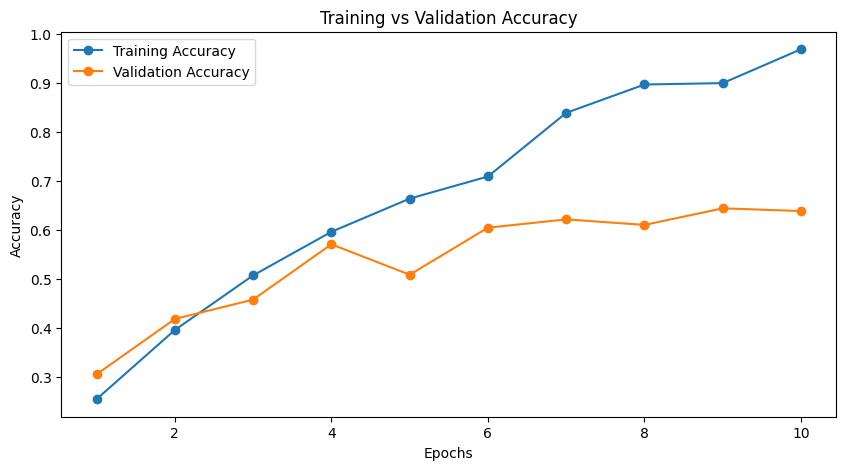

In [18]:
import matplotlib.pyplot as plt

train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, EPOCHS + 1)

plt.figure(figsize= (10,5))
plt.plot(epochs, train_accuracy, label = 'Training Accuracy', marker = 'o')
plt.plot(epochs, val_accuracy, label = 'Validation Accuracy', marker = 'o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [19]:
EPOCHS = 20

history = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = EPOCHS
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 92s 4s/step - accuracy: 0.9837 - loss: 0.0638 - val_accuracy: 0.6780 - val_loss: 1.6445
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 145s 4s/step - accuracy: 0.9856 - loss: 0.0598 - val_accuracy: 0.6554 - val_loss: 1.5738
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 93s 4s/step - accuracy: 0.9940 - loss: 0.0312 - val_accuracy: 0.6780 - val_loss: 1.5776
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 142s 4s/step - accuracy: 0.9888 - loss: 0.0515 - val_accuracy: 0.6836 - val_loss: 1.4615
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 90s 4s/step - accuracy: 0.9945 - loss: 0.0255 - val_accuracy: 0.6554 - val_loss: 1.8821
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 94s 4s/step - accuracy: 0.9961 - loss: 0.0194 - val_accuracy: 0.6384 - val_loss: 1.5127
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 138s 4s/step - accuracy: 0.9972 - loss: 0.0188 - val_accuracy: 0.6497 - val_loss: 1.6517
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 145s 4s/step - accuracy: 0.9916 - loss: 0.0322 - val_accuracy: 0.6497 - val_l

Solve the Overfitting problem


In [13]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=3)

In [14]:
from tensorflow.keras.callbacks import LearningRateScheduler

def scheduler(epoch,lr):
  if epoch > 5:
    return lr*0.1
  return lr

lr_schedule = LearningRateScheduler(scheduler)

In [15]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Rescaling(1.0/255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))

# Convolution layer: 1
model.add(tf.keras.layers.Conv2D(32, (3,3), activation="relu"))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Dropout(0.3))

# Convolution layer: 2
model.add(tf.keras.layers.Conv2D(64, (3,3), activation="relu"))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Dropout(0.3))

# Convolution layer: 3
model.add(tf.keras.layers.Conv2D(128, (3,3), activation="relu"))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Dropout(0.3))

# Flattening
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dropout(0.5))

# FCL
model.add(tf.keras.layers.Dense(128, activation="relu"))

# Output layer
model.add(tf.keras.layers.Dense(num_classes, activation="softmax"))

In [16]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [24]:
EPOCHS = 10

In [25]:
history = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = EPOCHS
)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 144s 6s/step - accuracy: 0.3083 - loss: 35.9985 - val_accuracy: 0.1412 - val_loss: 33.8764
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 139s 6s/step - accuracy: 0.4280 - loss: 1.7624 - val_accuracy: 0.1977 - val_loss: 77.4757
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 140s 6s/step - accuracy: 0.4691 - loss: 1.2898 - val_accuracy: 0.2203 - val_loss: 79.1702
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 142s 6s/step - accuracy: 0.5779 - loss: 1.1139 - val_accuracy: 0.1638 - val_loss: 72.1556
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 139s 6s/step - accuracy: 0.5765 - loss: 1.0576 - val_accuracy: 0.2825 - val_loss: 40.0891
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 139s 6s/step - accuracy: 0.6500 - loss: 0.8925 - val_accuracy: 0.3164 - val_loss: 12.1636
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 143s 6s/step - accuracy: 0.6236 - loss: 0.9644 - val_accuracy: 0.2655 - val_loss: 5.3426
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 139s 6s/step - accuracy: 0.6709 - loss: 0.8922 - val_accuracy: 0.2

In [17]:
import tensorflow as tf
from tensorflow.keras.layers import (
    RandomFlip, RandomRotation, RandomZoom,
    Rescaling, Conv2D, BatchNormalization, MaxPooling2D,
    Flatten, Dropout, Dense, GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

In [18]:
data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.15),
    RandomZoom(0.15),
    # Optional: add RandomContrast(0.2) if colors vary a lot
])

Grok.com's recommendation


In [19]:
import tensorflow as tf
from tensorflow.keras.layers import (
    RandomFlip, RandomRotation, RandomZoom,
    Rescaling, Conv2D, BatchNormalization, MaxPooling2D,
    Flatten, Dropout, Dense, GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

# -------------------------------
# Data Augmentation (Critical fix)
# -------------------------------


# -------------------------------
# Build the Model
# -------------------------------
model = tf.keras.models.Sequential()

# Input + Augmentation + Rescaling
model.add(data_augmentation)
model.add(Rescaling(1.0/255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))

# Conv Block 1
model.add(Conv2D(32, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(Conv2D(32, (3,3), activation="relu", padding="same"))  # Extra layer for better features
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

# Conv Block 2
model.add(Conv2D(64, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

# Conv Block 3
model.add(Conv2D(128, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(Conv2D(128, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.35))

# Classifier
model.add(Flatten())
# Alternative (often better): use GlobalAveragePooling2D() instead of Flatten()
# model.add(GlobalAveragePooling2D())

model.add(Dense(256, activation="relu", kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(128, activation="relu", kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.5))

# Output layer
model.add(Dense(num_classes, activation="softmax"))

# -------------------------------
# Compile with lower initial LR
# -------------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),  # Reduced from default 1e-3
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# -------------------------------
# Callbacks
# -------------------------------
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,           # More patient now that we have augmentation
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,           # Halve LR when plateau
    patience=3,
    min_lr=1e-7,
    verbose=1
)

callbacks = [early_stopping, reduce_lr]

# -------------------------------
# Train the model
# -------------------------------
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=50,  # Allow more epochs since early stopping will protect us
    callbacks=callbacks,
    verbose=1
)

# Optional: Print final results
print("\nTraining complete!")
print(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}")

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 419s 17s/step - accuracy: 0.2744 - loss: 3.2340 - val_accuracy: 0.2429 - val_loss: 3.4144 - learning_rate: 3.0000e-04
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 424s 17s/step - accuracy: 0.4024 - loss: 2.6654 - val_accuracy: 0.2429 - val_loss: 3.9644 - learning_rate: 3.0000e-04
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 373s 16s/step - accuracy: 0.4018 - loss: 2.6915 - val_accuracy: 0.2429 - val_loss: 3.7203 - learning_rate: 3.0000e-04
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 389s 17s/step - accuracy: 0.3909 - loss: 2.7078 - val_accuracy: 0.2429 - val_loss: 3.0565 - learning_rate: 3.0000e-04
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 393s 17s/step - accuracy: 0.4393 - loss: 2.4808 - val_accuracy: 0.2429 - val_loss: 4.1222 - learning_rate: 3.0000e-04
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 370s 16s/step - accuracy: 0.4432 - loss: 2.5307 - val_accuracy: 0.2429 - val_loss: 6.2356 - learning_rate: 3.0000e-04
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16s/step - accuracy: 0.4815 - loss

Transfer Learning - MobileNetV2


In [20]:
#MobileNetV2 base model

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [22]:
base_model.trainable = False

model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Input(shape=(224,224,3)))
model.add(data_augmentation)
model.add(tf.keras.layers.Rescaling(1.0/255))

model.add(base_model)
model.add(tf.keras.layers.GlobalAveragePooling2D())

model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))

In [23]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [25]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.3605 - loss: 1.6138 - val_accuracy: 0.5876 - val_loss: 1.0847
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.6841 - loss: 0.8713 - val_accuracy: 0.7288 - val_loss: 0.8538
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.7455 - loss: 0.7241 - val_accuracy: 0.5876 - val_loss: 1.0486
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.7665 - loss: 0.6399 - val_accuracy: 0.6723 - val_loss: 0.9478
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.7998 - loss: 0.5064 - val_accuracy: 0.7119 - val_loss: 0.8512
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 89s 3s/step - accuracy: 0.7877 - loss: 0.5726 - val_accuracy: 0.5932 - val_loss: 1.1991
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.8335 - loss: 0.4639 - val_accuracy: 0.6384 - val_loss: 0.9413
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.8580 - loss: 0.4129 - val_accuracy: 0.7119 - val_loss:

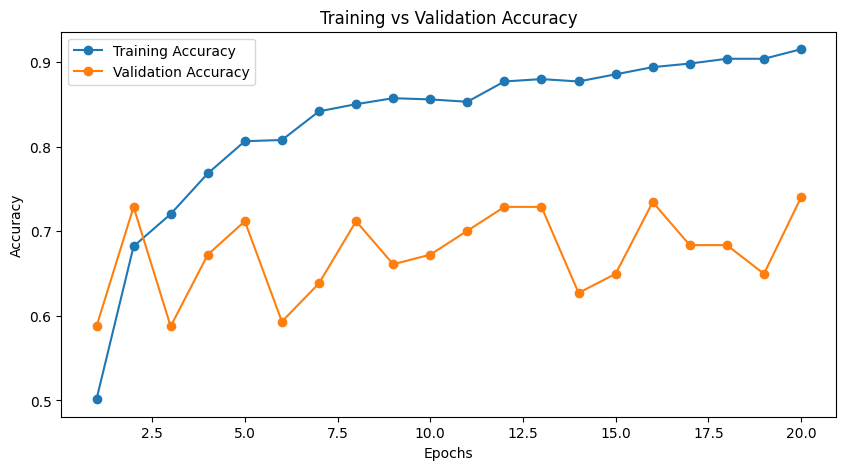

In [27]:
import matplotlib.pyplot as plt

train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, 21)

plt.figure(figsize= (10,5))
plt.plot(epochs, train_accuracy, label = 'Training Accuracy', marker = 'o')
plt.plot(epochs, val_accuracy, label = 'Validation Accuracy', marker = 'o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [29]:
model.save('/content/drive/MyDrive/Solar Panel Classification/mobilenetv2_2.h5')

## EfficientNet


In [30]:
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input

In [31]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split = 0.2,
    subset="training",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size = BATCH_SIZE,
    seed = SEED
)

Found 885 files belonging to 6 classes.
Using 708 files for training.


In [32]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split = 0.2,
    subset="validation",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size = BATCH_SIZE,
    seed = SEED
)

Found 885 files belonging to 6 classes.
Using 177 files for validation.


In [33]:
class_names = train_dataset.class_names

In [34]:
class_names

['Bird-drop',
 'Clean',
 'Dusty',
 'Electrical-damage',
 'Physical-Damage',
 'Snow-Covered']

In [35]:
num_classes = len(class_names)

In [36]:
num_classes

6

In [38]:
import os

class_counts = {}
total_images = 0

for class_name in class_names:
  class_path = os.path.join(DATASET_DIR, class_name)
  count = len(os.listdir(class_path))
  class_counts[class_name] = count
  total_images += count

In [39]:
class_weights = {}

for index, class_name in enumerate(class_names):
  class_weights[index] = total_images / (num_classes * class_counts[class_name])

print("Class weights", class_weights)

Class weights {0: 0.75, 1: 0.75, 2: 0.7657894736842106, 3: 1.412621359223301, 4: 2.108695652173913, 5: 1.1829268292682926}


In [40]:
data_augmentation = tf.keras.Sequential()
data_augmentation.add(tf.keras.layers.RandomFlip("horizontal"))
data_augmentation.add(tf.keras.layers.RandomRotation(0.1))
data_augmentation.add(tf.keras.layers.RandomZoom(0.1))

In [41]:
train_images = []
train_labels = []

In [42]:
for images, labels in train_dataset:
  images = preprocess_input(images)
  train_images.append(images)
  train_labels.append(labels)

In [43]:
train_images = tf.concat(train_images, axis=0)
train_labels = tf.concat(train_labels, axis=0)

In [44]:
validation_images = []
validation_labels = []

In [45]:
for images, labels in validation_dataset:
  images = preprocess_input(images)
  validation_images.append(images)
  validation_labels.append(labels)

In [46]:
validation_images = tf.concat(validation_images, axis=0)
validation_labels = tf.concat(validation_labels, axis=0)

In [47]:
base_model = tf.keras.applications.EfficientNetB0(
    input_shape = (224,224,3),
    include_top = False,
    weights="imagenet"
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [48]:
base_model.trainable = False

In [49]:
model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Input(shape=(224,224,3)))
model.add(data_augmentation)

model.add(base_model)
model.add(tf.keras.layers.GlobalAveragePooling2D())

model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))

In [50]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [51]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_6 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,313 (16.08 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [52]:
history = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = 15
)

Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 103s 4s/step - accuracy: 0.4221 - loss: 1.4404 - val_accuracy: 0.6158 - val_loss: 0.9275
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 139s 4s/step - accuracy: 0.7320 - loss: 0.7656 - val_accuracy: 0.6949 - val_loss: 0.7748
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.7800 - loss: 0.5933 - val_accuracy: 0.6949 - val_loss: 0.7522
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 88s 4s/step - accuracy: 0.8314 - loss: 0.4912 - val_accuracy: 0.7684 - val_loss: 0.6578
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 85s 4s/step - accuracy: 0.8510 - loss: 0.4635 - val_accuracy: 0.7627 - val_loss: 0.6562
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 86s 4s/step - accuracy: 0.8800 - loss: 0.3623 - val_accuracy: 0.7458 - val_loss: 0.6452
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 84s 4s/step - accuracy: 0.9002 - loss: 0.3100 - val_accuracy: 0.7345 - val_loss: 0.6818
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 149s 4s/step - accuracy: 0.8894 - loss: 0.3236 - val_accuracy: 0.7571 - val_lo

Hyper Parameter Optimization


In [53]:
!pip install keras-tuner  # Run if not installed

import keras_tuner as kt
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

# Reuse your train_dataset and validation_dataset (with preprocess_input already applied)
# Make sure they are defined as in your original code

def build_model(hp):
    base_model = EfficientNetB0(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = False

    model = Sequential([
        RandomFlip("horizontal"),
        RandomRotation(hp.Float("rotation_factor", min_value=0.05, max_value=0.3, step=0.05)),
        RandomZoom(hp.Float("zoom_factor", min_value=0.05, max_value=0.3, step=0.05)),
        base_model,
        GlobalAveragePooling2D(),
        Dropout(hp.Float("dropout_rate", min_value=0.0, max_value=0.5, step=0.1)),
        Dense(
            hp.Int("dense_units", min_value=64, max_value=512, step=64),
            activation='relu'
        ),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Setup Random Search Tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=20,          # Same as n_iter before
    executions_per_trial=1,
    directory='kt_dir',
    project_name='efficientnet_tune',
    overwrite=True
)

# Optional: Early stopping
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

# Run the search
tuner.search(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20,
    callbacks=[early_stopping],
    class_weight=class_weights  # Handles imbalance
)

# Results
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:")
print(best_hps.values)

best_model = tuner.get_best_models(num_models=1)[0]

# Evaluate on validation
val_loss, val_acc = best_model.evaluate(validation_dataset)
print(f"Best validation accuracy: {val_acc:.4f}")

Trial 20 Complete [00h 19m 49s]
val_accuracy: 0.7457627058029175

Best val_accuracy So Far: 0.8305084705352783
Total elapsed time: 07h 16m 16s
Best hyperparameters:
{'rotation_factor': 0.05, 'zoom_factor': 0.2, 'dropout_rate': 0.0, 'dense_units': 320, 'learning_rate': 0.0007427145219259959}


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


6/6 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.8461 - loss: 0.4954
Best validation accuracy: 0.8305


In [54]:
model.save('/content/drive/MyDrive/Solar Panel Classification/trained_effnet_finetune.h5')